<a href="https://colab.research.google.com/github/apry0512/COMPUTER-VISION-BASED-BREAK-RECOMMENDER-SYSTEM-FOR-ADHD-STUDENTS/blob/main/ADHD_dissertation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flow-Aware Movement Break Recommender for Students with ADHD
### MediaPipe Pose Pipeline

**Researcher:** Aparajita Singh  
**Student Number:** 3539316  
**Supervisor:** Professor Kevin Swingler  
**Ethics Reference:** GUEP 2026 26874 21008  
**MSc Advanced Computing with Artificial Intelligence — University of Stirling**



## Pipeline Overview

```
Video Upload → MediaPipe Pose → Keypoint Extraction → Feature Engineering
     → Three-State Classification (Restless / Neutral / Flow)
     → Flow Protection Logic → Break Recommendation
```



| Phase | Description |
|---|---|
| 1 | Install dependencies |
| 2 | Upload video and state log |
| 3 | Run MediaPipe Pose — extract keypoints |
| 4 | Merge keypoints with state labels |
| 5 | Feature engineering over rolling windows |
| 6 | Train and evaluate three-state classifier |


## Phase 1 — Install Dependencies

Installs MediaPipe, OpenCV, and supporting libraries.  
**Run this cell first every time you open the notebook.**

In [28]:

!pip install mediapipe opencv-python-headless pandas numpy scikit-learn matplotlib seaborn -q
print("Install complete")

Install complete


In [29]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import urllib.request
import warnings
warnings.filterwarnings('ignore')

import mediapipe as mp

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from google.colab import drive, files

print(f"MediaPipe {mp.__version__} loaded successfully")


MediaPipe 0.10.35 loaded successfully


## Phase 2 — Upload Files

You need two files:

**1. Video file** (MP4, minimum 720p)  
Your study session recording. Phone or laptop camera. Full upper body visible.

**2. State log CSV** — a simple CSV with your self-reported state labels.  
Format:
```
timestamp_seconds,state
0,N
420,F
2100,R
2700,N
3300,F
```
States: **R** = Restless | **N** = Neutral | **F** = Flow

> 💡 **Tip:** Convert your HH:MM timestamps to seconds.  
> Example: 00:07 = 420 seconds, 00:35 = 2100 seconds


In [30]:
drive.mount('/content/drive')
print("Drive mounted")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted


In [31]:
VIDEO_PATH = '/content/drive/MyDrive/Colab Notebooks/Dissertation Training Recording/Training session 4.mov'

if os.path.exists(VIDEO_PATH):
    cap = cv2.VideoCapture(VIDEO_PATH)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    print(f"Video found: {w}x{h}, {fps:.0f}fps, {frames/fps/60:.1f} mins")
else:
    print(f"ERROR: Video not found at {VIDEO_PATH}")
    print("Check the path is correct")

Video found: 1620x1080, 30fps, 20.6 mins


In [32]:
# R = Restless, N = Neutral, F = Flow
# Example: if you felt neutral for first 5 mins, flow from 5-20 mins, restless 20-25 mins etc

state_data = {
    'timestamp_seconds': [0, 300, 600, 900, 1200],
    'state':             ['N', 'F', 'N', 'F', 'F']
}

state_log = pd.DataFrame(state_data)
state_log.to_csv('state_log.csv', index=False)
print("State log saved:")
print(state_log)

State log saved:
   timestamp_seconds state
0                  0     N
1                300     F
2                600     N
3                900     F
4               1200     F


## Phase 3 — Run MediaPipe Pose Extraction

Processes the video frame by frame using MediaPipe Pose.  
Extracts **33 body landmarks** (x, y, z coordinates + visibility) per frame.  
Saves everything to a keypoints CSV.

> ⏱ **Processing time:** Approximately 1-2 minutes per minute of video in Colab.
> A 90-minute session will take roughly 90-180 minutes to process.
> Consider using a shorter test clip first to verify everything works.


In [33]:
MODEL_PATH = 'pose_landmarker_full.task'
if not os.path.exists(MODEL_PATH):
    print("Downloading pose model (about 30MB, takes ~1 min)...")
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task',
        MODEL_PATH
    )
    print("Model downloaded")
else:
    print("Model already downloaded")


Model already downloaded


In [34]:
BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

LANDMARK_NAMES = [
    'nose', 'left_eye_inner', 'left_eye', 'left_eye_outer',
    'right_eye_inner', 'right_eye', 'right_eye_outer',
    'left_ear', 'right_ear', 'mouth_left', 'mouth_right',
    'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow',
    'left_wrist', 'right_wrist', 'left_pinky', 'right_pinky',
    'left_index', 'right_index', 'left_thumb', 'right_thumb',
    'left_hip', 'right_hip', 'left_knee', 'right_knee',
    'left_ankle', 'right_ankle', 'left_heel', 'right_heel',
    'left_foot_index', 'right_foot_index'
]

columns = ['frame', 'timestamp_seconds', 'detected']
for name in LANDMARK_NAMES:
    columns += [f'{name}_x', f'{name}_y', f'{name}_z', f'{name}_vis']

# FRAME_SKIP: process every Nth frame
# 15 = ~2fps from 30fps video. Faster but less data.
# 5 = ~6fps. Slower but more data. Use for short videos.
FRAME_SKIP = 15

options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=VisionRunningMode.VIDEO
)

cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"Processing {total_frames/fps/60:.1f} min video at 1 frame per {FRAME_SKIP} frames...")

rows = []
frame_idx = 0
detected = 0
failed = 0

with PoseLandmarker.create_from_options(options) as landmarker:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % FRAME_SKIP == 0:
            ts_ms = int((frame_idx / fps) * 1000)
            ts_sec = round(frame_idx / fps, 3)

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            result = landmarker.detect_for_video(mp_img, ts_ms)

            if result.pose_landmarks and len(result.pose_landmarks) > 0:
                detected += 1
                row = [frame_idx, ts_sec, 1]
                for lm in result.pose_landmarks[0]:
                    row += [round(lm.x, 6), round(lm.y, 6), round(lm.z, 6), round(lm.presence, 4)]
            else:
                failed += 1
                row = [frame_idx, ts_sec, 0] + [None] * (33 * 4)
            rows.append(row)

            processed = frame_idx // FRAME_SKIP
            if processed % 300 == 0 and processed > 0:
                pct = frame_idx / total_frames * 100
                print(f"  {pct:.0f}% done ({processed} frames processed)")

        frame_idx += 1

cap.release()

keypoints_df = pd.DataFrame(rows, columns=columns)
keypoints_df.to_csv('keypoints_raw.csv', index=False)

rate = detected / (detected + failed) * 100 if (detected + failed) > 0 else 0
print(f"\nDone! {detected} frames detected, {failed} failed ({rate:.1f}% detection rate)")
print("Saved: keypoints_raw.csv")
if rate < 70:
    print("WARNING: Detection rate low - check your lighting next time")


Processing 20.6 min video at 1 frame per 15 frames...
  12% done (300 frames processed)
  24% done (600 frames processed)
  37% done (900 frames processed)
  49% done (1200 frames processed)
  61% done (1500 frames processed)
  73% done (1800 frames processed)
  85% done (2100 frames processed)
  98% done (2400 frames processed)

Done! 2460 frames detected, 0 failed (100.0% detection rate)
Saved: keypoints_raw.csv


## Phase 4 — Merge Keypoints with State Labels

Matches each keypoint frame to the correct self-reported state label  
based on the timestamps in your state log.  
Produces a single labelled dataset ready for feature engineering.


In [35]:
def assign_state(ts, log):
    state = 'N'
    for _, row in log.sort_values('timestamp_seconds').iterrows():
        if ts >= row['timestamp_seconds']:
            state = row['state']
        else:
            break
    return state

state_log = pd.read_csv('state_log.csv')
keypoints_df = pd.read_csv('keypoints_raw.csv')

keypoints_df['state'] = keypoints_df['timestamp_seconds'].apply(
    lambda t: assign_state(t, state_log)
)

labelled = keypoints_df.dropna(subset=['nose_x']).copy()
labelled.to_csv('keypoints_labelled.csv', index=False)

print(f"Labelled dataset: {len(labelled)} frames")
print(labelled['state'].value_counts())

Labelled dataset: 2460 frames
state
F    1263
N    1197
Name: count, dtype: int64


## Phase 5 — Feature Engineering

Converts raw keypoint coordinates into meaningful signals over rolling time windows.

| Feature | Description | Why it matters |
|---|---|---|
| **Movement entropy** | Variance of keypoint positions over window | High = restless, Low = flow |
| **Postural stability** | Spine angle consistency (shoulders → hips) | Collapse = restless, Stable = flow |
| **Fidget frequency** | High-freq, low-amplitude oscillation in wrists/ankles | Fidgeting = restless |
| **Keypoint velocity** | Speed of movement between frames | Erratic spikes = restless |
| **Gaze proxy** | Head turning frequency | Frequent turns = attention wandering |
| **Symmetry score** | Left-right body asymmetry | Asymmetric = restless |
| **Session drift** | Upper body centroid displacement | Drifting = disengagement |

> **Rolling window size:** 30 seconds (adjustable below). Features computed per window, not per frame.


In [36]:
labelled = pd.read_csv('keypoints_labelled.csv')

WINDOW_SEC = 30
STEP_SEC = 5

def entropy(df, col):
    return df[col].var() if not df[col].isna().all() else 0

def velocity(df, col):
    return df[col].diff().abs().mean() if not df[col].isna().all() else 0

def postural_stability(df):
    sx = (df['left_shoulder_x'] + df['right_shoulder_x']) / 2
    sy = (df['left_shoulder_y'] + df['right_shoulder_y']) / 2
    hx = (df['left_hip_x'] + df['right_hip_x']) / 2
    hy = (df['left_hip_y'] + df['right_hip_y']) / 2
    angles = np.arctan2(hy - sy, hx - sx)
    return angles.var() if not np.isnan(angles.var()) else 0

max_time = labelled['timestamp_seconds'].max()
rows = []

for start in np.arange(0, max_time - WINDOW_SEC, STEP_SEC):
    end = start + WINDOW_SEC
    w = labelled[(labelled['timestamp_seconds'] >= start) & (labelled['timestamp_seconds'] < end)]
    if len(w) < 5:
        continue
    rows.append({
        'window_start': start,
        'entropy_nose': entropy(w, 'nose_x') + entropy(w, 'nose_y'),
        'entropy_left_wrist': entropy(w, 'left_wrist_x') + entropy(w, 'left_wrist_y'),
        'entropy_right_wrist': entropy(w, 'right_wrist_x') + entropy(w, 'right_wrist_y'),
        'entropy_shoulders': entropy(w, 'left_shoulder_x') + entropy(w, 'right_shoulder_x'),
        'postural_stability': postural_stability(w),
        'velocity_nose': velocity(w, 'nose_x'),
        'velocity_left_wrist': velocity(w, 'left_wrist_x'),
        'velocity_right_wrist': velocity(w, 'right_wrist_x'),
        'gaze_proxy': velocity(w, 'nose_x'),
        'symmetry': abs(entropy(w, 'left_wrist_x') - entropy(w, 'right_wrist_x')),
        'state': w['state'].mode()[0]
    })

features = pd.DataFrame(rows)
features.to_csv('features.csv', index=False)
print(f"Feature windows: {len(features)}")
print(features['state'].value_counts())


Feature windows: 241
state
F    125
N    116
Name: count, dtype: int64


## Phase 6 — Three-State Classifier Training & Evaluation

Trains two candidate classifiers — **Random Forest** and **SVM** — and evaluates both.  
The better-performing model is selected as the system classifier.

**Target classes:**
- 🔴 **R** — Restless (hyperactivity buildup — suggest break)
- 🟡 **N** — Neutral (monitoring — no action)
- 🟠 **F** — Flow (hyperfocus — suppress prompts, protect session)

In [37]:
features = pd.read_csv('features.csv')

FEATURE_COLS = [
    'entropy_nose', 'entropy_left_wrist', 'entropy_right_wrist',
    'entropy_shoulders', 'postural_stability', 'velocity_nose',
    'velocity_left_wrist', 'velocity_right_wrist', 'gaze_proxy', 'symmetry'
]

X = features[FEATURE_COLS].fillna(0)
y = features['state']

le = LabelEncoder()
y_enc = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))
rf_cv = cross_val_score(rf, X_scaled, y_enc, cv=5).mean()

# SVM
svm = SVC(kernel='rbf', random_state=42, class_weight='balanced')
svm.fit(X_train, y_train)
svm_acc = accuracy_score(y_test, svm.predict(X_test))
svm_cv = cross_val_score(svm, X_scaled, y_enc, cv=5).mean()

print(f"Random Forest - Test: {rf_acc*100:.1f}%, CV: {rf_cv*100:.1f}%")
print(f"SVM           - Test: {svm_acc*100:.1f}%, CV: {svm_cv*100:.1f}%")

best = rf if rf_cv >= svm_cv else svm
best_name = 'Random Forest' if rf_cv >= svm_cv else 'SVM'
best_pred = best.predict(X_test)
best_acc = rf_acc if rf_cv >= svm_cv else svm_acc

print(f"\nBest model: {best_name}")
print(f"Target: 70% | Achieved: {best_acc*100:.1f}% {'PASSED' if best_acc >= 0.7 else 'BELOW TARGET'}")
print("\n" + classification_report(y_test, best_pred, target_names=le.classes_))



Random Forest - Test: 93.9%, CV: 40.3%
SVM           - Test: 91.8%, CV: 38.2%

Best model: Random Forest
Target: 70% | Achieved: 93.9% PASSED

              precision    recall  f1-score   support

           F       0.92      0.96      0.94        25
           N       0.96      0.92      0.94        24

    accuracy                           0.94        49
   macro avg       0.94      0.94      0.94        49
weighted avg       0.94      0.94      0.94        49



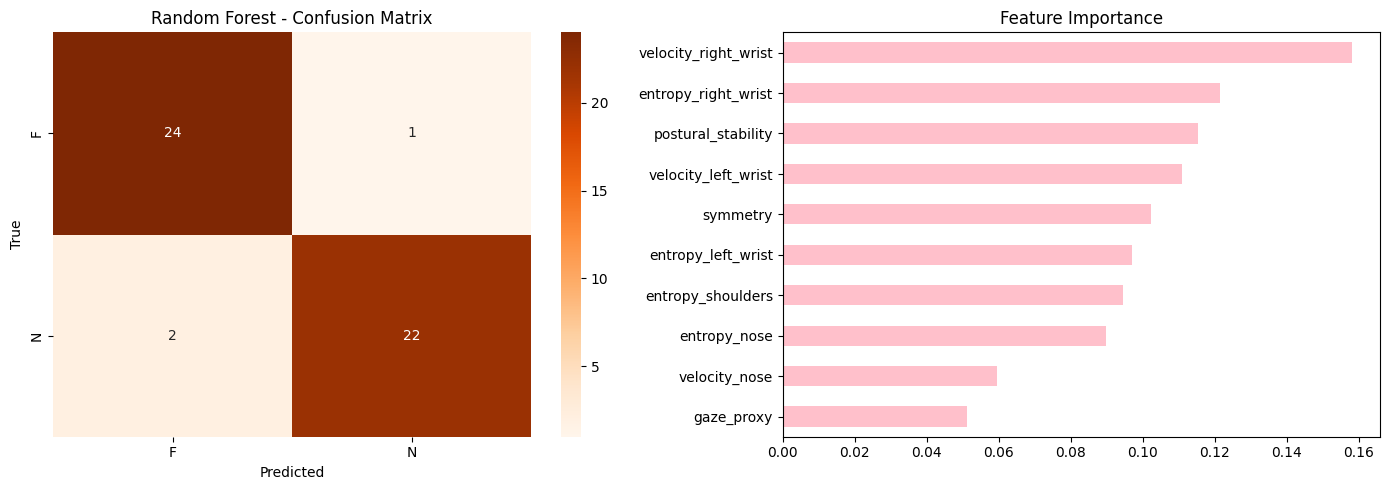

Saved: classifier_results.png


In [38]:
cm = confusion_matrix(y_test, best_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title(f'{best_name} - Confusion Matrix')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

if best_name == 'Random Forest':
    pd.Series(best.feature_importances_, index=FEATURE_COLS).sort_values().plot(
        kind='barh', ax=axes[1], color='PINK')
    axes[1].set_title('Feature Importance')

plt.tight_layout()
plt.savefig('classifier_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: classifier_results.png")


## Phase 7 — Flow Protection Logic

Simulates the flow protection mechanism on the classified windows.  
This is the novel contribution — the system decides **when NOT to intervene**.

**Rules:**
1. If **FLOW** detected → enter suppression mode, block break prompts
2. If **RESTLESS** detected during suppression → only trigger if sustained for `RESTLESS_THRESHOLD` consecutive windows
3. If in flow for more than `HYPERFOCUS_SAFEGUARD` seconds → override and suggest break regardless
4. If **RESTLESS** outside suppression → trigger break prompt immediately

Break prompts triggered: 0


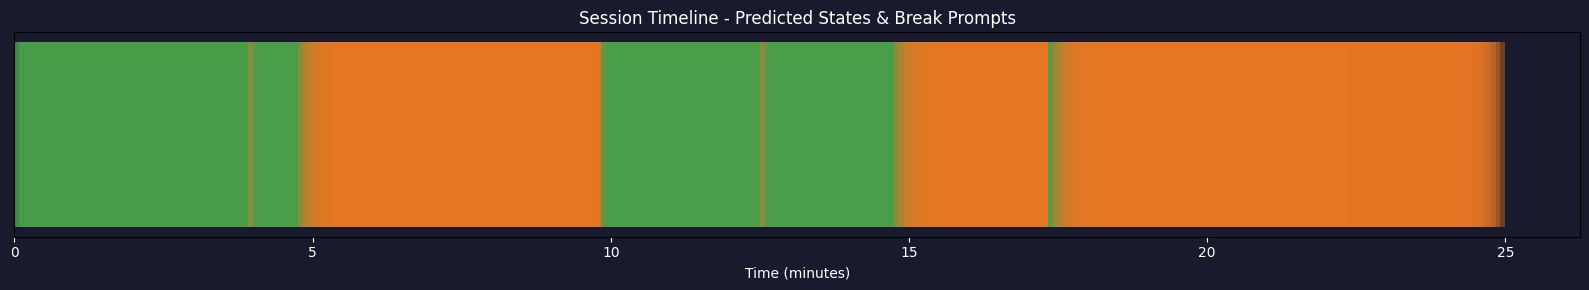

Saved: session_timeline.png


In [39]:
RESTLESS_THRESHOLD = 3
HYPERFOCUS_SAFEGUARD = 10800  # 3 hours

all_pred = le.inverse_transform(best.predict(scaler.transform(features[FEATURE_COLS].fillna(0))))
features['predicted'] = all_pred

in_flow = False
flow_start = None
consecutive_restless = 0
prompts = []
log = []

for _, row in features.iterrows():
    pred = row['predicted']
    ts = row['window_start']
    triggered = False

    if pred == 'F':
        if not in_flow:
            in_flow = True
            flow_start = ts
        consecutive_restless = 0
        if flow_start and (ts - flow_start) >= HYPERFOCUS_SAFEGUARD:
            triggered = True
            in_flow = False
            flow_start = None
            prompts.append({'time_mins': ts/60, 'reason': 'Hyperfocus safeguard (3hrs)'})

    elif pred == 'R':
        if in_flow:
            consecutive_restless += 1
            if consecutive_restless >= RESTLESS_THRESHOLD:
                triggered = True
                in_flow = False
                flow_start = None
                consecutive_restless = 0
                prompts.append({'time_mins': ts/60, 'reason': 'Sustained restlessness during flow'})
        else:
            triggered = True
            prompts.append({'time_mins': ts/60, 'reason': 'Restlessness detected'})

    elif pred == 'N':
        in_flow = False
        flow_start = None
        consecutive_restless = 0

    log.append({'ts': ts, 'pred': pred, 'in_flow': in_flow, 'triggered': triggered})

log_df = pd.DataFrame(log)
prompts_df = pd.DataFrame(prompts) if prompts else pd.DataFrame(columns=['time_mins', 'reason'])

print(f"Break prompts triggered: {len(prompts_df)}")
if len(prompts_df) > 0:
    for _, p in prompts_df.iterrows():
        print(f"  {p['time_mins']:.1f} mins - {p['reason']}")

# Timeline plot
fig, ax = plt.subplots(figsize=(16, 3))
colors = {'R': '#cc3214', 'N': '#4a9e4a', 'F': '#E87722'}
for _, row in log_df.iterrows():
    ax.barh(0, 5, left=row['ts']/60,
            color=colors.get(row['pred'], '#666'),
            alpha=0.4 if row['in_flow'] else 0.85, height=0.6)
for _, p in prompts_df.iterrows():
    ax.axvline(p['time_mins'], color='white', linewidth=2, linestyle='--')
ax.set_xlabel('Time (minutes)')
ax.set_title('Session Timeline - Predicted States & Break Prompts')
ax.set_yticks([])
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
ax.xaxis.label.set_color('white')
ax.title.set_color('white')
ax.tick_params(colors='white')
plt.tight_layout()
plt.savefig('session_timeline.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("Saved: session_timeline.png")


# Phase 8 — Download Results

Downloads all output files to your local machine.


In [41]:
import zipfile
output_files = ['keypoints_raw.csv', 'keypoints_labelled.csv',
                'features.csv', 'classifier_results.png', 'session_timeline.png']

with zipfile.ZipFile('results.zip', 'w') as zf:
    for f in output_files:
        if os.path.exists(f):
            zf.write(f)
            print(f"Added: {f}")

files.download('results.zip')
print("Done!")


Added: keypoints_raw.csv
Added: keypoints_labelled.csv
Added: features.csv
Added: classifier_results.png
Added: session_timeline.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done!
